In [78]:
using LinearAlgebra

"""
Checks if the point c is on the line segment ab
"""
function liesOnLineSegment(a, b, c)
    return min(a[1], b[1]) <= c[1] && c[1] <= max(a[1], b[1]) && min(a[2], b[2]) <= c[2] && c[2] <= max(a[2], b[2])
end

"""
Accepts 2 vectors of 4-Tuples of 2 points in the 2D plane and 2 parameters corresponding to them, each representing a polygon 
and returns a vector of 3-tuples of intersections between these 2 polygons 
and the parameters of the curves needed to get the intersection
"""
function poly_intersections(poly_p, poly_q)
    intersections = []
    #p1, p2 are points in R², tp1, tp2 in R are parameters such that p(tp1) = p1 and p(tp2) = p2, same holds for q1, q2, uq1, uq2
    for (p1, p2, tp1, tp2) in poly_p
        for (q1, q2, uq1, uq2) in poly_q
            d1 = det([p2[1]-p1[1] q1[1]-p1[1];
                      p2[2]-p1[2] q1[2]-p1[2]])
            d2 = det([p2[1]-p1[1] q2[1]-p1[1];
                      p2[2]-p1[2] q2[2]-p1[2]])
            d3 = det([q2[1]-q1[1] p1[1]-q1[1];
                      q2[2]-q1[2] p1[2]-q1[2]])
            d4 = det([q2[1]-q1[1] p2[1]-q1[1];
                      q2[2]-q1[2] p2[2]-q1[2]])
            
            if d1*d2 < 0 && d3*d4 < 0
                #we have an intersection, we can calculate it from parametrized line segments
                #solving for p(t) = q(u) where in this case p is a parametrization of the line
                #from points p1 to p2 and q is a parametrization of the line from q2 to q1
                #v1, v2 make it a bit easier to write the system 
                v1 = p2-p1
                v2 = q2-q1
                A = [v1[1] -v2[1]; v1[2] -v2[2]]
                b = [q1[1] - p1[1], q1[2] - p1[2]]

                #backslash operator for solving the linear system
                x = A \ b 
                s, r = x[1], x[2]
                #linear approximation for parameters, will work good if h is small
                t = tp1 + s*(tp2-tp1)
                u = uq1 + r*(uq2-uq1)
                #calculating the actual intersection point
                intersection = p1 + s * v1
                push!(intersections, (intersection, t, u))
            
            elseif iszero(d1) && liesOnLineSegment(p1, p2, q1)
                s = norm(q1 - p1) / norm(p2 - p1)
                t = tp1 + s*(tp2-tp1)
                push!(intersections, (q1, t, uq1))
            
            elseif iszero(d2) && liesOnLineSegment(p1, p2, q2)
                s = norm(q2 - p1) / norm(p2 - p1)
                t = tp1 + s*(tp2-tp1)
                push!(intersections, (q2, t, uq2))
            
            elseif iszero(d3) && liesOnLineSegment(q1, q2, p1)
                r = norm(p1-q1) / norm(q2-q1)
                u = uq1 + r*(uq2-uq1)
                push!(intersections, (p1, tp1, u))
            
            elseif iszero(d4) && liesOnLineSegment(q1, q2, p2)
                r = norm(p2-q1) / norm(q2-q1)
                u = uq1 + r*(uq2-uq1)
                push!(intersections, (p2, tp2, u))
            
            else
                #no intersection
            end
        end
    end
    
    return intersections
end

"""
The function accepts p, q which are collumn vectors and represent the curves of which we are trying to find intersections of, 
pdot, qdot which are also collumn vectors and are their derivatives, intp, intq are 2-tuples and represent the interval at which
we are interested to find intersections at, h is a float and represents the step size for evaluating the curves, so it should be sufficiently small.
polychains is an optional parameter if we want to also return the points used for building the polychains alongside their intersections. 
"""
function intersectionOfCurves(p, pdot, intp, q, qdot, intq, h; polychains = false, maxiter = 1000, tolerance = 1e-12)
    #get the parameters for the polygonal approximation from the given intervals and step size
    n = Int(floor((intp[2]-intp[1])/h))
    m = Int(floor((intq[2]-intq[1])/h))
    p_params = [intp[1]+k*h for k in 0:n]
    q_params = [intq[1]+k*h for k in 0:m]
    
    if p_params[end] < intp[2]
        push!(p_params, intp[2]) #if the length of the interval isnt divisible by h we add the last parameter, which is the right border of the interval, separately
    end 
    
    if q_params[end] < intq[2]    
        push!(q_params, intq[2])
    end
    
    #build the polygonal chain as tuples of points and parameters (p1, p2, tp1, tp2), (p2, p3, tp2, tp3), ..., (pn-1, pn, tpn-1, tpn)
    poly_p = [(p(p_params[i]), p(p_params[i+1]), p_params[i], p_params[i+1]) for i in 1:length(p_params)-1]
    poly_q = [(q(q_params[i]), q(q_params[i+1]), q_params[i], q_params[i+1]) for i in 1:length(q_params)-1]
  
    polychain_intersections = poly_intersections(poly_p, poly_q) #a vector of intersections and parameters at those intersections
    
    improved_intersections = []
    #Run the newton method on all starting approximations of intersections to improve them
    for (I, t0, q0) in polychain_intersections
        
        x_r = [t0, q0]
        i = 1

        for outer i in 1:maxiter
            F = p(x_r[1]) - q(x_r[2])
            JF = [pdot(x_r[1]) -qdot(x_r[2])]
            delta = JF \ F
            x_r = x_r - delta
            if norm(delta) < tolerance
                break
            end
        end

        if i == maxiter
            @warn "no convergence after $maxiter iterations"
        end
        push!(improved_intersections, Tuple(p(x_r[1])))
    end
    
    Q = [Tuple(polychain_intersections[i][1]) for i in 1:length(polychain_intersections)]
    
    #I need this for plotting the polychains
    if polychains
        return (P=improved_intersections, Q=Q, Polys = (poly_p, poly_q))
    end
    
    return (P = improved_intersections, Q = Q)
end

function get_poly_coords(poly_chain)
    # Because we have (p1, p2), (p2, p3), ..., (pn-1, pn) 
    # it is enough to take the first point out from every pair
    x_coords = [pair[1][1] for pair in poly_chain]
    y_coords = [pair[1][2] for pair in poly_chain]

    # And add pn separately in the end 
    push!(x_coords, poly_chain[end][2][1])
    push!(y_coords, poly_chain[end][2][2])
    
    return x_coords, y_coords
end


get_poly_coords (generic function with 1 method)

In [79]:
intv = [0, 2*pi]
h = 0.1
n = floor((intv[2]-intv[1])/h)
p_points = [intv[1]+k*h for k in 0:n]
p(x) = [cos(x); sin(x)]
pp = [(p(t), p(t+h)) for t in p_points]
push!(pp, (pp[end][2], pp[1][1]))

64-element Vector{Tuple{Vector{Float64}, Vector{Float64}}}:
 ([1.0, 0.0], [0.9950041652780258, 0.09983341664682815])
 ([0.9950041652780258, 0.09983341664682815], [0.9800665778412416, 0.19866933079506122])
 ([0.9800665778412416, 0.19866933079506122], [0.955336489125606, 0.2955202066613396])
 ([0.955336489125606, 0.2955202066613396], [0.9210609940028851, 0.3894183423086505])
 ([0.9210609940028851, 0.3894183423086505], [0.8775825618903728, 0.479425538604203])
 ([0.8775825618903728, 0.479425538604203], [0.8253356149096783, 0.5646424733950354])
 ([0.8253356149096782, 0.5646424733950355], [0.7648421872844884, 0.6442176872376911])
 ([0.7648421872844884, 0.6442176872376911], [0.6967067093471654, 0.7173560908995228])
 ([0.6967067093471654, 0.7173560908995228], [0.6216099682706644, 0.7833269096274834])
 ([0.6216099682706644, 0.7833269096274834], [0.5403023058681398, 0.8414709848078965])
 ([0.5403023058681398, 0.8414709848078965], [0.4535961214255773, 0.8912073600614354])
 ([0.4535961214255773, 0

In [80]:
p(t) = [t; 3*cos(t)]
pdot(t) = [1; -3*sin(t)]
intp = (-2*pi, 2*pi)
q(u) = [u; 2*sin(u)]
qdot(u) = [1; 2*cos(u)]
intq = (-2*pi, 2*pi)
h = 0.1
P, Q = intersectionOfCurves(p, pdot, intp, q, qdot, intq, h; maxiter=10, polychains=true)


(P = Any[(-5.3003915839322575, 1.6641005886756874), (-2.1587989303424644, -1.6641005886756877), (0.9827937232473292, 1.6641005886756872), (4.124386376837123, -1.6641005886756863)], Q = [(-5.300407165568014, 1.6629149890381298), (-2.158783180236887, -1.6625662361311928), (0.9827817641462526, 1.6622331002492392), (4.12439628326985, -1.663517972579316)], Polys = ([([-6.283185307179586, 3.0], [-6.183185307179587, 2.9850124958340776], -6.283185307179586, -6.183185307179587), ([-6.183185307179587, 2.9850124958340776], [-6.083185307179586, 2.9401997335237247], -6.183185307179587, -6.083185307179586), ([-6.083185307179586, 2.9401997335237247], [-5.983185307179586, 2.866009467376818], -6.083185307179586, -5.983185307179586), ([-5.983185307179586, 2.866009467376818], [-5.883185307179586, 2.7631829820086544], -5.983185307179586, -5.883185307179586), ([-5.883185307179586, 2.7631829820086544], [-5.783185307179586, 2.632747685671118], -5.883185307179586, -5.783185307179586), ([-5.783185307179586, 2.

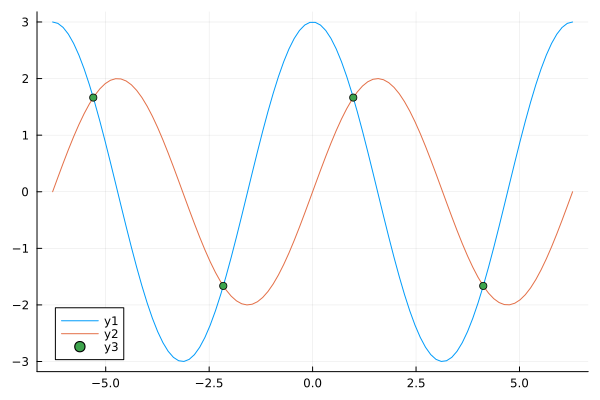

In [81]:
using Plots
t = LinRange(-2*pi, 2*pi, 100)
u = LinRange(-2*pi, 2*pi, 100)

plot(t, 3*cos.(t))
plot!(u, 2*sin.(u))
xin = [collect(P)[i][1] for i in 1:length(P)]
yin = [collect(P)[i][2] for i in 1:length(P)]
scatter!(xin, yin)
xip = [collect(Q)[i][1] for i in 1:length(Q)]
yip = [collect(Q)[i][2] for i in 1:length(Q)]

norm(xin - xip) + norm(yin - yip)
plot!()

In [82]:
#The curves separately
p1(t) = [16*(sin.(t)) .^ 3; 13*cos.(t) - 5*cos.(2*t) - 2*cos.(3*t) - cos.(4*t)]
p1dot(t) = [48*((sin.(t)) .^ 2)*cos.(t); 13*sin.(t) + 10*sin.(2*t) + 6*sin.(3*t) + 4*sin.(4*t)]
q1(u) = [u; sin.(u) .* u]
q1dot(u) = [1; cos.(u) .* u + sin.(u)]
intvp1 = (-2*pi, 2*pi)
intvq1 = (-20, 20)
h = 0.1

u = LinRange(-20, 20, 500)
t = LinRange(-2*pi, 2*pi, 500)
ppoints = [p1(x) for x in t]
qpoints = [q1(x) for x in u]

x1_vals = [pt[1] for pt in ppoints]
y1_vals = [pt[2] for pt in ppoints]
x2_vals = [qu[1] for qu in qpoints]
y2_vals = [qu[2] for qu in qpoints]

plt = plot(x1_vals, y1_vals, label="Curve p1 (h=0.1)", color="red", legend = :top, title="The love and catastrophic sine curve intersections")
plot!(plt, x2_vals, y2_vals, label="Curve q1 (h=0.1)", color="green")

P1, Q1 = intersectionOfCurves(p1, p1dot, intvp1, q1, q1dot, intvq1, h)
newton_intersection_x = [collect(P1)[i][1] for i in 1:length(P1)]
newton_intersection_y = [collect(P1)[i][2] for i in 1:length(P1)]
scatter!(plt, newton_intersection_x, newton_intersection_y, color="blue", label="Intersections")
savefig(plt, "Love and catastrophic sine curve intersections.pdf")


"/home/boobsson/Desktop/3. letnik FRI/MM/HW2/Love and catastrophic sine curve intersections.pdf"

In [83]:
P11, Q11, Poly = intersectionOfCurves(p1, p1dot, intvp1, q1, q1dot, intvq1, 0.3, polychains=true)

(P = Any[(13.381660025721539, 9.740832378780361), (15.203254228872982, 7.351575821188107), (15.608485699838573, 1.5501346110254688), (12.262232971278545, -3.6721771265012166), (10.042552236180963, -5.816869737735069), (-10.042552236180974, -5.8168697377350576), (-12.262232971278554, -3.6721771265012038), (-15.608485699838463, 1.5501346110251204), (-15.203254228872977, 7.351575821188116), (-13.38166002572151, 9.74083237878039), (13.381660025721576, 9.740832378780324), (15.203254228872982, 7.35157582118811), (15.608485699838715, 1.550134611025908), (10.042552236180965, -5.8168697377350655), (12.26223297127855, -3.6721771265012078), (-10.042552236180915, -5.816869737735112), (-12.262232971278545, -3.6721771265012166), (-13.381660025721539, 9.740832378780361), (-15.20325422887318, 7.351575821187713), (-13.381660025721487, 9.740832378780407)], Q = [(13.358260422360262, 9.445026246599891), (15.274890304739909, 6.318240441820016), (15.489142447186216, 3.3181086914855986), (12.29396058994933, 

In [84]:
#Polychain separately
xp1, yp1 = get_poly_coords(Poly[1])
xq1, yq1 = get_poly_coords(Poly[2])
pltpoly = plot(xp1, yp1, label="Polychain P1 (h=0.3)", ls=:solid, marker=:circle, ms=2, alpha=0.6, legend=:top, color="red", title="The love and catastrophic sine polychain intersections")
plot!(pltpoly, xq1, yq1, label="Polychain Q1 (h=0.3)", ls=:solid, marker=:circle, ms=2, alpha=0.6, color = "green")
poly_intersections_x = [collect(Q11)[i][1] for i in 1:length(Q11)]
poly_intersections_y = [collect(Q11)[i][2] for i in 1:length(Q11)]
scatter!(pltpoly, poly_intersections_x, poly_intersections_y, color="blue", label="Polychain intersections")
savefig(pltpoly, "Polychain intersections.pdf")

"/home/boobsson/Desktop/3. letnik FRI/MM/HW2/Polychain intersections.pdf"

In [85]:
#Both on the same graqh
P12, Q12 = intersectionOfCurves(p1, p1dot, intvp1, q1, q1dot, intvq1, 0.3)
newton_intersection_x = [collect(P12)[i][1] for i in 1:length(P12)]
newton_intersection_y = [collect(P12)[i][2] for i in 1:length(P12)]
plt1 = plot(x1_vals, y1_vals, label=false, color="red", legend = :top, title="The love and catastrophic sine curve intersections")
plot!(plt1, x2_vals, y2_vals, label=false, color="green")
scatter!(plt1, newton_intersection_x, newton_intersection_y, color="blue", label="Improved intersections")
plot!(plt1, xp1, yp1, label=false, ls=:solid, marker=:circle, ms=2, alpha=0.5, legend=:top, color="orange")
plot!(plt1, xq1, yq1, label=false, ls=:solid, marker=:circle, ms=2, alpha=0.5, color = "yellow")
scatter!(plt1, poly_intersections_x, poly_intersections_y, color="black", label="Polychain intersections")
savefig(plt1, "Curve and polychain intersections.pdf")

"/home/boobsson/Desktop/3. letnik FRI/MM/HW2/Curve and polychain intersections.pdf"